In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sb

In [121]:
df = pd.read_csv(r"/Users/loganheydt/Desktop/Data/GitHub/Titanic-Prediction/Data/train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [122]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [123]:
drop_cols = ['PassengerId', 'Name', 'Cabin']
one_hot_cols = ['Sex', 'Embarked']
impute_cols = ['Age']

# Need to drop the 2 null embarked 

In [124]:
def transform_data(df):

    modeling_df = df.copy()

    # Dropped null Embarked
    modeling_df = modeling_df.dropna(subset=['Embarked'])

    # Imputed Age
    imputer = SimpleImputer(strategy='mean')
    imputer.fit(modeling_df[impute_cols])
    x_imputed = imputer.transform(modeling_df[impute_cols])
    modeling_df[impute_cols] = pd.DataFrame(x_imputed, columns=impute_cols, index=modeling_df.index)

    # Dropped unneccesary columns
    modeling_df.drop(columns=drop_cols, inplace= True)

    # One Hot Encoding
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded = encoder.fit_transform(modeling_df[one_hot_cols])
    one_hot_df = pd.DataFrame(one_hot_encoded, columns= encoder.get_feature_names_out(one_hot_cols), index=modeling_df.index)
    modeling_df = pd.concat([modeling_df.drop(columns=one_hot_cols, axis=1), one_hot_df], axis=1)

    # Ticket string to number
    modeling_df['Ticket'] = modeling_df['Ticket'].str.extract(r'(\d+)\s*$')

    modeling_df['is_child'] = (modeling_df['Age'] < 18).astype(int)

    return modeling_df

modeling_df = transform_data(df)

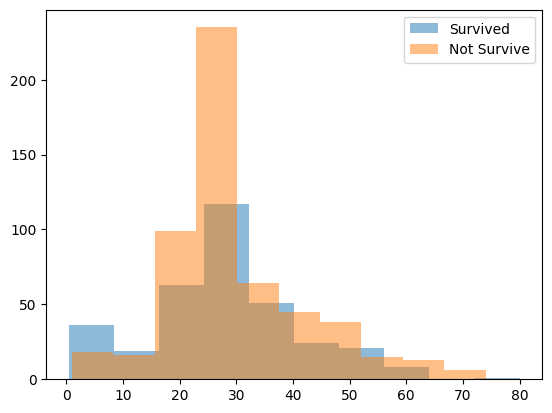

In [125]:
survived = modeling_df[modeling_df['Survived'] == 1]
not_survive = modeling_df[modeling_df['Survived'] == 0]

plt.hist(survived['Age'], alpha=.5, label='Survived')
plt.hist(not_survive['Age'], alpha=.5,  label= 'Not Survive')
plt.legend()
plt.show()

In [126]:
target_dist = modeling_df['Survived'].value_counts(normalize=True)
target_dist

Survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

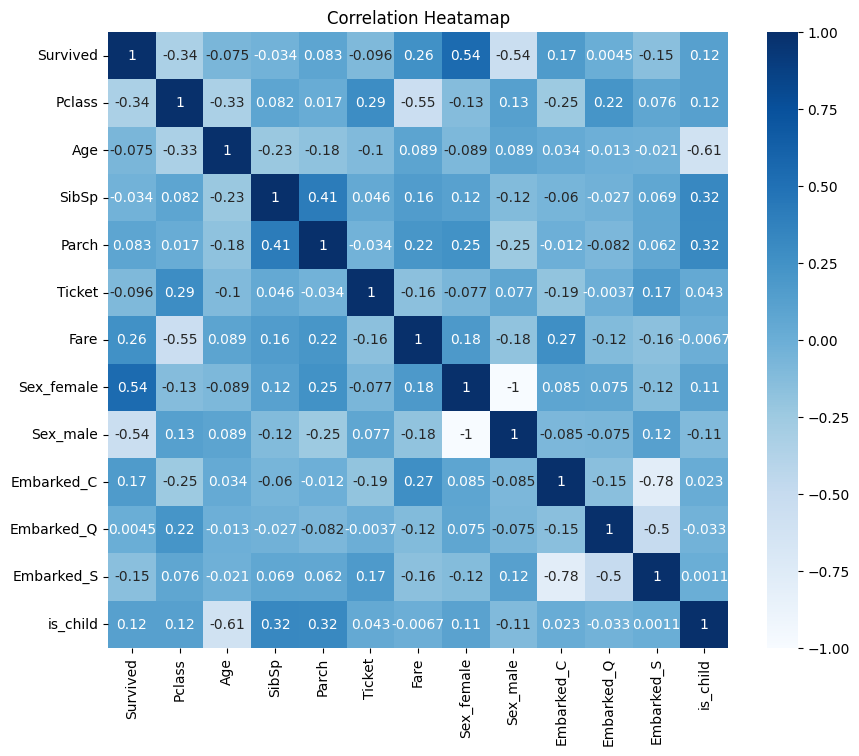

In [127]:
plt.figure(figsize=(10,8))
corr = modeling_df.corr()
sb.heatmap(corr, cmap='Blues', annot=True)
plt.title("Correlation Heatamap")
plt.show()